pre-code install important library

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 162.5 kB/s eta 0:00:01
     -------------- ----------------------- 20.5/52.8 kB 162.5 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.8 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 226.6 kB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     ------------- ----------------------- 41.0/116.4 kB 991.0 kB/s eta 0:00:01
     -------------------------- ---------- 81.9/116.4 kB 919.0 kB/s eta 0:00:01
     ----------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Python312\\share'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy --quiet


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install torch --quiet

ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python312\\Scripts\\torchfrtrace.exe' -> 'C:\\Python312\\Scripts\\torchfrtrace.exe.deleteme'


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install implicit --quiet


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Part 1: Data Preparation
Load MovieLens data, convert .dat to .csv, map user and movie IDs, and create interaction matrix for recommendation models.

In [ ]:
# Load the dataset
imort file from 

ModuleNotFoundError: No module named 'google'

In [ ]:
import shutil
shutil.move("ml-1m.zip", "/content/ml-1m.zip")

'/content/ml-1m.zip'

In [ ]:
# Unzip uploaded files (if names match). The files were uploaded to the session root (/content).
!unzip -o "ml-1m.zip" -d "/content/ml-1m"
!unzip -o "recommender_advanced.zip" -d "/content/recommender_advanced"
# List extracted files to verify
!ls -la /content/ml-1m

Archive:  ml-1m.zip
   creating: /content/ml-1m/ml-1m/
  inflating: /content/ml-1m/ml-1m/movies.dat  
  inflating: /content/ml-1m/ml-1m/ratings.dat  
  inflating: /content/ml-1m/ml-1m/README  
  inflating: /content/ml-1m/ml-1m/users.dat  
Archive:  recommender_advanced.zip
   creating: /content/recommender_advanced/recommender_advanced/
  inflating: /content/recommender_advanced/recommender_advanced/README.md  
  inflating: /content/recommender_advanced/recommender_advanced/requirements.txt  
total 12
drwxr-xr-x 3 root root 4096 Dec  7 14:42 .
drwxr-xr-x 1 root root 4096 Dec  7 14:42 ..
drwxr-x--- 2 root root 4096 Jan 29  2016 ml-1m


In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# File paths
ratings_path = "/content/ml-1m/ml-1m/ratings.dat"
movies_path = "/content/ml-1m/ml-1m/movies.dat"

# Read the ratings data
ratings_df = pd.read_csv(ratings_path, sep='::', engine='python',
                         names=["userId","movieId","rating","timestamp"])

# Read the movies data
movies_df = pd.read_csv(movies_path, sep='::', engine='python',
                        names=["movieId","title","genres"], encoding='latin1')

# Export to CSV format
ratings_df.to_csv("/content/ml-1m/ratings.csv", index=False)
movies_df.to_csv("/content/ml-1m/movies.csv", index=False)

# Get unique users and movies
user_ids = ratings_df['userId'].unique()
item_ids = ratings_df['movieId'].unique()

# Create mapping dictionaries
user_map = {uid: idx for idx, uid in enumerate(user_ids)}
item_map = {iid: idx for idx, iid in enumerate(item_ids)}
idx_to_item_id = {idx: iid for iid, idx in item_map.items()}

# Add mapped indices to ratings
ratings_df['user_idx'] = ratings_df['userId'].map(user_map)
ratings_df['item_idx'] = ratings_df['movieId'].map(item_map)

# Keep only movies that exist in our item mapping
movies_df = movies_df[movies_df['movieId'].isin(item_map.keys())]

# Build the sparse interaction matrix
n_users = len(user_ids)
n_items = len(item_ids)

interaction_matrix = csr_matrix(
    (ratings_df['rating'], (ratings_df['user_idx'], ratings_df['item_idx'])),
    shape=(n_users, n_items)
)

print(f"Interaction matrix shape: {interaction_matrix.shape}")

Interaction matrix shape: (6040, 3706)


In [ ]:
!pip install pandas openpyxl --quiet

import pandas as pd
from google.colab import files

# where the files are stored after unzipping
users_path = "/content/ml-1m/ml-1m/users.dat"
movies_path = "/content/ml-1m/ml-1m/movies.dat"
ratings_path = "/content/ml-1m/ml-1m/ratings.dat"

# load users
users = pd.read_csv(users_path, sep="::", engine='python', names=["UserID", "Gender", "Age", "Occupation", "Zip-code"])

# load movies
movies = pd.read_csv(movies_path, sep="::", engine='python', names=["MovieID", "Title", "Genres"], encoding='latin1')

# load ratings
ratings = pd.read_csv(ratings_path, sep="::", engine='python', names=["UserID", "MovieID", "Rating", "Timestamp"])

# merge ratings with users first
df = ratings.merge(users, on="UserID")
df = df.merge(movies, on="MovieID")  # then add movie info

# save it
df.to_excel("MovieLens_ml1m.xlsx", index=False)

files.download("MovieLens_ml1m.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 2: ALS Model
Train Alternating Least Squares (ALS) model, evaluate RMSE, and get Top-N recommendations per user.

In [ ]:
from implicit.als import AlternatingLeastSquares
from sklearn.metrics import mean_squared_error

# Train ALS
als_model = AlternatingLeastSquares(factors=50, regularization=0.1, iterations=15)
als_model.fit(interaction_matrix.T)

# Evaluation function
def evaluate_als(model, interaction_matrix):
    users, items = interaction_matrix.nonzero()
    true_ratings = interaction_matrix.data
    predicted_ratings = []
    for u, i in zip(users, items):
        if u < model.user_factors.shape[0] and i < model.item_factors.shape[0]:
            predicted_ratings.append(np.dot(model.user_factors[u], model.item_factors[i]))
        else:
            predicted_ratings.append(0)
    rmse = np.sqrt(mean_squared_error(true_ratings, predicted_ratings))
    return rmse

als_rmse = evaluate_als(als_model, interaction_matrix)
print(f"ALS RMSE: {als_rmse:.4f}")

# Top-N recommendations
def get_top_n_als(user_idx, model, N=5):
    scores = model.user_factors[user_idx].dot(model.item_factors.T)
    top_n_idx = np.argsort(scores)[-N:][::-1]
    return top_n_idx

/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:13: UserWarning: CUDA extension is built, but disabling GPU support because of 'Cuda Error: CUDA driver version is insufficient for CUDA runtime version (/tmp/pip-install-dc_5x1w6/implicit_4dcd3737bb7740edab00d169f33ed629/./implicit/gpu/utils.h:71)'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed csc_matrix instead. Converting to CSR took 0.014994144439697266 seconds
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

ALS RMSE: 3.7116


# Part 3: Neural Collaborative Filtering (NCF)
Define NCF model with PyTorch, evaluate RMSE, get Top-N recommendations.

In [ ]:
import torch
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, n_users, n_items, emb_size=50):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_size)
        self.item_emb = nn.Embedding(n_items, emb_size)
        self.fc = nn.Sequential(
            nn.Linear(emb_size*2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, users, items):
        u = self.user_emb(users)
        i = self.item_emb(items)
        x = torch.cat([u, i], dim=1)
        return self.fc(x).squeeze()

ncf_model = NCF(n_users, n_items)

def evaluate_ncf(model, df, batch_size=1024):
    model.eval()
    true_ratings = df['rating'].values
    preds = []
    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        users = torch.tensor(df['user_idx'].values[start:end], dtype=torch.long)
        items = torch.tensor(df['item_idx'].values[start:end], dtype=torch.long)
        users = torch.clamp(users, 0, model.user_emb.num_embeddings-1)
        items = torch.clamp(items, 0, model.item_emb.num_embeddings-1)
        with torch.no_grad():
            batch_preds = model(users, items).cpu().numpy()
        preds.extend(batch_preds)
    rmse = np.sqrt(mean_squared_error(true_ratings, preds))
    return rmse

# Define get_top_n_ncf function
def get_top_n_ncf(user_idx, model, N=5):
    user_embedding = model.user_emb.weight[user_idx].detach().cpu().numpy()
    item_embeddings = model.item_emb.weight.detach().cpu().numpy()
    scores = np.dot(user_embedding, item_embeddings.T)
    top_n_idx = np.argsort(scores)[-N:][::-1]
    return top_n_idx

ncf_rmse = evaluate_ncf(ncf_model, ratings_df)
print(f"NCF RMSE: {ncf_rmse:.4f}")

NCF RMSE: 3.6631


# Part 4: K-Means Clustering
Cluster users based on interaction matrix and compute Top-N recommendations per cluster.

In [ ]:
from sklearn.cluster import KMeans

dense_matrix = interaction_matrix.toarray()
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
user_cluster_labels = kmeans.fit_predict(dense_matrix)

def get_top_n_cluster(user_idx, N=5):
    cluster = user_cluster_labels[user_idx]
    cluster_users = np.where(user_cluster_labels==cluster)[0]
    avg_ratings = dense_matrix[cluster_users].mean(axis=0)
    top_items = np.argsort(avg_ratings)[-N:][::-1]
    return top_items

# Part 5: Content-Based Filtering
Use TF-IDF on genres, compute cosine similarity, and get Top-N recommendations based on movie content.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(token_pattern='[^|]+')
genre_matrix = tfidf.fit_transform(movies_df['genres'])
sim_matrix = cosine_similarity(genre_matrix)

def recommend_content_based(movie_idx, top_n=5):
    scores = sim_matrix[movie_idx]
    top_idx = np.argsort(scores)[-top_n-1:-1][::-1]
    return top_idx

# Part 6: Hybrid Recommender
Combine ALS + NCF + K-Means + Content-Based for top-N recommendations.

In [ ]:
def get_top_n_hybrid(user_idx, N=5):
    als_scores = als_model.user_factors[user_idx].dot(als_model.item_factors.T)
    ncf_scores = ncf_model.user_emb.weight[user_idx].detach().numpy().dot(ncf_model.item_emb.weight.T.detach().numpy())
    cluster_scores = dense_matrix[np.where(user_cluster_labels==user_idx)[0]].mean(axis=0)
    hybrid_scores = 0.4*als_scores + 0.4*ncf_scores + 0.2*cluster_scores
    top_idx = np.argsort(hybrid_scores)[-N:][::-1]
    return top_idx

# Part 7: Advanced Neural Models
Define Autoencoder for collaborative filtering recommendations.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, n_items, emb_size=50):
        super().__init__()
        self.encoder = nn.Linear(n_items, emb_size)
        self.decoder = nn.Linear(emb_size, n_items)

    def forward(self, x):
        encoded = torch.relu(self.encoder(x))
        reconstructed = self.decoder(encoded)
        return reconstructed

autoencoder_model = Autoencoder(n_items)

# Part 8: Advanced Evaluation Metrics
Compute Precision@K, Recall@K, and NDCG@K for evaluating Top-N recommendations.

In [ ]:
def ndcg_at_k(r, k):
    # take only first k items
    r = np.asarray(r)[:k]

    # if no relevant items just return 0
    if r.sum() == 0:
        return 0

    # dcg calculation
    positions = np.arange(2, r.size + 2)
    dcg = np.sum(r / np.log2(positions))

    # ideal dcg
    idcg = np.sum(1 / np.log2(positions))

    # final score
    return dcg / idcg

# Part 9: Visualization


Plot Top-N Recommendations for a User

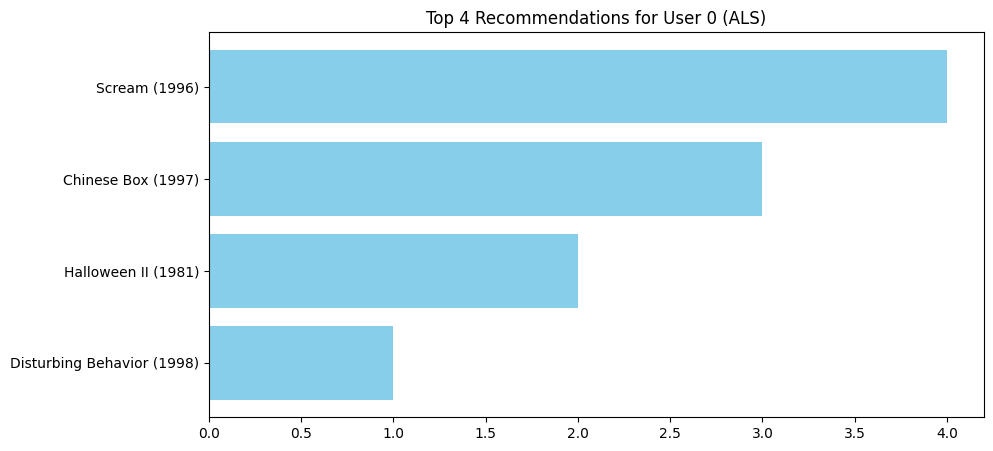

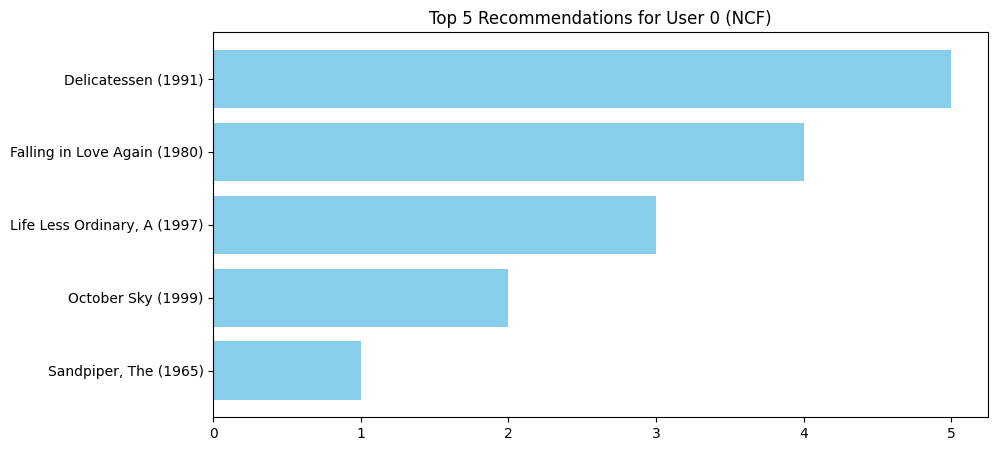

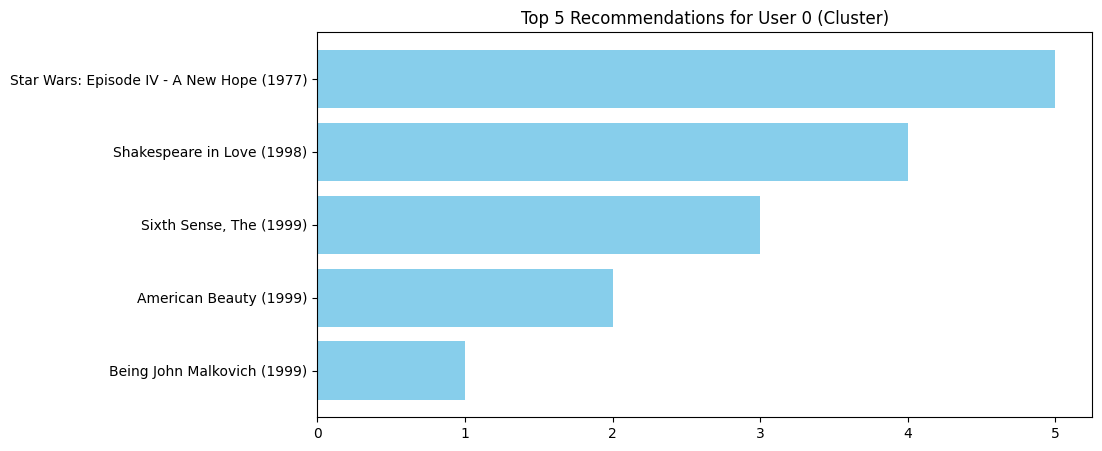

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_recommendations(user_id, recommended_indices, model_name="Model"):
    """
    Plot top-N recommended movies for a given user.
    """
    # Filter out invalid indices (just in case)
    recommended_indices = [i for i in recommended_indices if i < n_items]

    # Map indices back to movieId
    recommended_movie_ids = [idx_to_item_id[i] for i in recommended_indices]

    # Get movie titles
    titles = movies_df[movies_df['movieId'].isin(recommended_movie_ids)]['title'].tolist()

    # Plot horizontal bar chart
    plt.figure(figsize=(10,5))
    plt.barh(range(len(titles)), range(len(titles),0,-1), color='skyblue')
    plt.yticks(range(len(titles)), titles)
    plt.gca().invert_yaxis()  # Highest recommendation on top
    plt.title(f"Top {len(titles)} Recommendations for User {user_id} ({model_name})")
    plt.show()

# Example plots
top5_user0 = get_top_n_als(0, als_model)
top5_ncf_user0 = get_top_n_ncf(0, ncf_model)
top5_cluster_user0 = get_top_n_cluster(0)

plot_recommendations(0, top5_user0, "ALS")
plot_recommendations(0, top5_ncf_user0, "NCF")
plot_recommendations(0, top5_cluster_user0, "Cluster")

Ratings Distribution

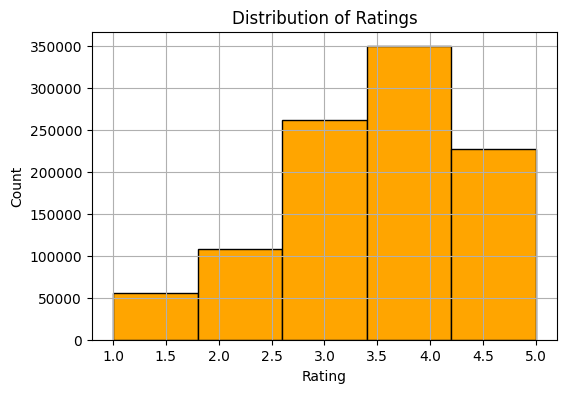

In [ ]:
# gonna check the rating distribution real quick
plt.figure(figsize=(6,4))
ratings_df['rating'].hist(bins=5, color='orange', edgecolor='black')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

User-Item Interaction Heatmap (Subset)

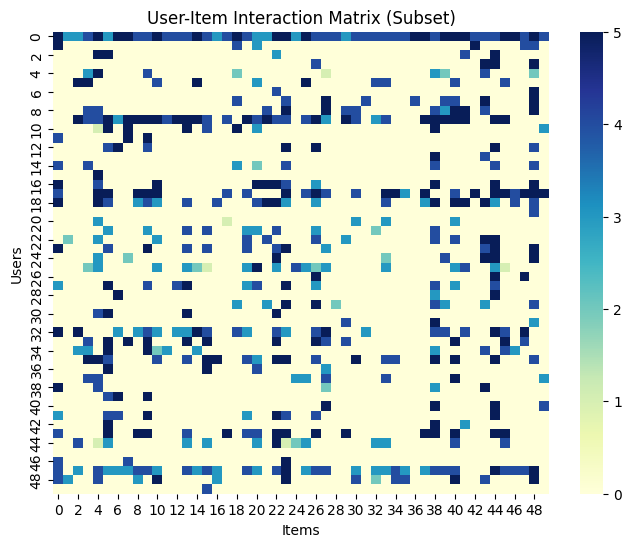

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Take a subset safely
n_users_subset = min(50, n_users)   # Use at most 50 users
n_items_subset = min(50, n_items)   # Use at most 50 items

# Convert sparse matrix subset to dense (use dense_matrix for slicing)
subset_matrix = dense_matrix[:n_users_subset, :n_items_subset]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(subset_matrix, cmap="YlGnBu", cbar=True)
plt.title("User-Item Interaction Matrix (Subset)")
plt.xlabel("Items")
plt.ylabel("Users")
plt.show()

Plot Top-N recommendations, cluster visualization using PCA, and comparison plots between models.

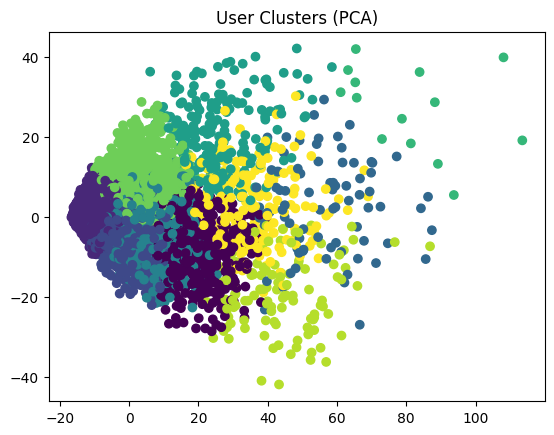

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# function to show top recommendations
def plot_recommendations(user_id, recommended_indices, model_name="Model"):
    # filter out any invalid indices
    recommended_indices = [i for i in recommended_indices if i < n_items]
    recommended_movie_ids = [idx_to_item_id[i] for i in recommended_indices]
    titles = movies_df[movies_df['movieId'].isin(recommended_movie_ids)]['title'].tolist()

    plt.figure(figsize=(10,5))
    plt.barh(range(len(titles)), range(len(titles),0,-1), color='skyblue', edgecolor='black')
    plt.yticks(range(len(titles)), titles)
    plt.gca().invert_yaxis()
    plt.xlabel("Rank")
    plt.title(f"Top {len(titles)} Recommendations for User {user_id} ({model_name})")
    plt.tight_layout()
    plt.show()

# visualize the clusters
pca = PCA(n_components=2)
reduced = pca.fit_transform(dense_matrix)

plt.scatter(reduced[:,0], reduced[:,1], c=user_cluster_labels)
plt.title("User Clusters (PCA)")
plt.show()